# Program 5 - Gated Recurrent Unit (GRU) Implementation


## 1. Install & Import Libraries

In [1]:
# Install required libraries (uncomment if needed)
# !pip install torch numpy matplotlib scikit-learn

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')

Libraries imported successfully!
PyTorch version: 2.10.0+cpu


## 2. GRU from Scratch (NumPy)

In [2]:
class GRUCellNumpy:
    """
    GRU Cell implemented from scratch using NumPy.
    Gates:
      - Update Gate (z): controls how much past info to keep
      - Reset Gate  (r): controls how much past info to forget
      - Candidate Hidden State (h_tilde)
    """
    def __init__(self, input_size, hidden_size):
        self.input_size  = input_size
        self.hidden_size = hidden_size
        scale = 0.01

        # --- Update Gate weights ---
        self.Wz = np.random.randn(hidden_size, input_size)  * scale
        self.Uz = np.random.randn(hidden_size, hidden_size) * scale
        self.bz = np.zeros((hidden_size, 1))

        # --- Reset Gate weights ---
        self.Wr = np.random.randn(hidden_size, input_size)  * scale
        self.Ur = np.random.randn(hidden_size, hidden_size) * scale
        self.br = np.zeros((hidden_size, 1))

        # --- Candidate hidden state weights ---
        self.Wh = np.random.randn(hidden_size, input_size)  * scale
        self.Uh = np.random.randn(hidden_size, hidden_size) * scale
        self.bh = np.zeros((hidden_size, 1))

    def sigmoid(self, x):
        return 1 / (1 + np.exp(-x))

    def forward(self, x, h_prev):
        """
        x      : input  shape (input_size, 1)
        h_prev : previous hidden state shape (hidden_size, 1)
        Returns: h_next (hidden_size, 1)
        """
        # Update gate
        z = self.sigmoid(self.Wz @ x + self.Uz @ h_prev + self.bz)

        # Reset gate
        r = self.sigmoid(self.Wr @ x + self.Ur @ h_prev + self.br)

        # Candidate hidden state
        h_tilde = np.tanh(self.Wh @ x + self.Uh @ (r * h_prev) + self.bh)

        # New hidden state
        h_next = (1 - z) * h_prev + z * h_tilde

        return h_next, z, r, h_tilde

print('GRUCellNumpy class defined!')

GRUCellNumpy class defined!


## 3. Test the NumPy GRU Cell

In [3]:
np.random.seed(42)

input_size  = 3
hidden_size = 5
seq_length  = 10

gru_cell = GRUCellNumpy(input_size, hidden_size)

# Random input sequence
X = np.random.randn(seq_length, input_size, 1)

# Initial hidden state
h = np.zeros((hidden_size, 1))

print('Processing sequence through NumPy GRU...')
print(f'Input shape per step : {X[0].shape}')
print(f'Hidden state shape   : {h.shape}\n')

for t in range(seq_length):
    h, z, r, h_tilde = gru_cell.forward(X[t], h)
    print(f'Step {t+1:2d} | Update gate mean: {z.mean():.4f} | Reset gate mean: {r.mean():.4f} | h_next mean: {h.mean():.4f}')

print(f'\nFinal hidden state:\n{h.flatten()}')

Processing sequence through NumPy GRU...
Input shape per step : (3, 1)
Hidden state shape   : (5, 1)

Step  1 | Update gate mean: 0.5011 | Reset gate mean: 0.4988 | h_next mean: 0.0018
Step  2 | Update gate mean: 0.4939 | Reset gate mean: 0.5021 | h_next mean: 0.0030
Step  3 | Update gate mean: 0.4982 | Reset gate mean: 0.5011 | h_next mean: 0.0018
Step  4 | Update gate mean: 0.5003 | Reset gate mean: 0.5001 | h_next mean: 0.0015
Step  5 | Update gate mean: 0.4982 | Reset gate mean: 0.5014 | h_next mean: -0.0003
Step  6 | Update gate mean: 0.5046 | Reset gate mean: 0.4978 | h_next mean: -0.0002
Step  7 | Update gate mean: 0.5028 | Reset gate mean: 0.4986 | h_next mean: 0.0006
Step  8 | Update gate mean: 0.5042 | Reset gate mean: 0.4978 | h_next mean: 0.0010
Step  9 | Update gate mean: 0.5012 | Reset gate mean: 0.4999 | h_next mean: -0.0010
Step 10 | Update gate mean: 0.4963 | Reset gate mean: 0.5018 | h_next mean: -0.0003

Final hidden state:
[-0.00072057  0.00141453 -0.00192145 -0.002

## 4. Generate Synthetic Time-Series Data

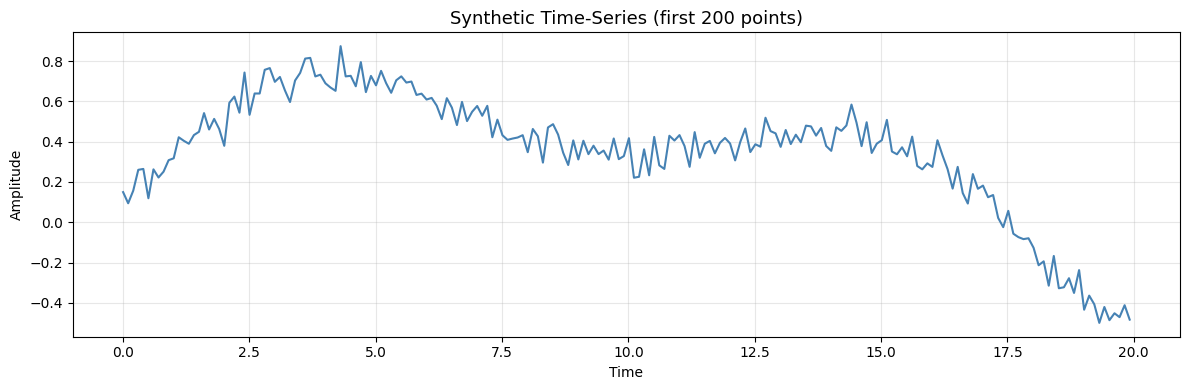

Total data points: 1000


In [4]:
np.random.seed(0)
torch.manual_seed(0)

# Generate a noisy sine wave
t       = np.linspace(0, 100, 1000)
signal  = np.sin(0.2 * t) + 0.5 * np.sin(0.5 * t) + 0.1 * np.random.randn(len(t))

# Normalize
scaler  = MinMaxScaler(feature_range=(-1, 1))
signal_scaled = scaler.fit_transform(signal.reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 4))
plt.plot(t[:200], signal_scaled[:200], color='steelblue', linewidth=1.5)
plt.title('Synthetic Time-Series (first 200 points)', fontsize=13)
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f'Total data points: {len(signal_scaled)}')

## 5. Prepare Sequences for PyTorch GRU

In [5]:
def create_sequences(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i : i + seq_len])
        ys.append(data[i + seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN   = 30
TRAIN_SPLIT = 0.8

X_all, y_all = create_sequences(signal_scaled, SEQ_LEN)

split = int(len(X_all) * TRAIN_SPLIT)
X_train, X_test = X_all[:split], X_all[split:]
y_train, y_test = y_all[:split], y_all[split:]

# Convert to tensors: shape (batch, seq_len, features)
X_train_t = torch.tensor(X_train, dtype=torch.float32).unsqueeze(-1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(-1)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(-1)
y_test_t  = torch.tensor(y_test,  dtype=torch.float32).unsqueeze(-1)

print(f'Train samples : {X_train_t.shape}')
print(f'Test  samples : {X_test_t.shape}')

Train samples : torch.Size([776, 30, 1])
Test  samples : torch.Size([194, 30, 1])


## 6. Define PyTorch GRU Model

In [6]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(GRUModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.gru = nn.GRU(
            input_size  = input_size,
            hidden_size = hidden_size,
            num_layers  = num_layers,
            batch_first = True,
            dropout     = dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size)
        out, _ = self.gru(x, h0)     # out: (batch, seq_len, hidden)
        out = self.fc(out[:, -1, :]) # take last time step
        return out

model = GRUModel()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f'\nTotal trainable parameters: {total_params:,}')

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)

Total trainable parameters: 37,889


## 7. Train the GRU Model

In [7]:
EPOCHS    = 100
LR        = 0.001
BATCH_SIZE = 32

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=30, gamma=0.5)

train_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    perm = torch.randperm(X_train_t.size(0))
    epoch_loss = 0.0
    batches = 0

    for i in range(0, X_train_t.size(0), BATCH_SIZE):
        idx     = perm[i : i + BATCH_SIZE]
        xb, yb  = X_train_t[idx], y_train_t[idx]

        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        epoch_loss += loss.item()
        batches    += 1

    avg_loss = epoch_loss / batches
    train_losses.append(avg_loss)
    scheduler.step()

    if epoch % 10 == 0:
        print(f'Epoch [{epoch:3d}/{EPOCHS}]  Loss: {avg_loss:.6f}  LR: {scheduler.get_last_lr()[0]:.6f}')

print('\nTraining complete!')

Epoch [ 10/100]  Loss: 0.006181  LR: 0.001000
Epoch [ 20/100]  Loss: 0.005370  LR: 0.001000
Epoch [ 30/100]  Loss: 0.005181  LR: 0.000500
Epoch [ 40/100]  Loss: 0.005088  LR: 0.000500
Epoch [ 50/100]  Loss: 0.004898  LR: 0.000500
Epoch [ 60/100]  Loss: 0.005261  LR: 0.000250
Epoch [ 70/100]  Loss: 0.004777  LR: 0.000250
Epoch [ 80/100]  Loss: 0.004707  LR: 0.000250
Epoch [ 90/100]  Loss: 0.004858  LR: 0.000125
Epoch [100/100]  Loss: 0.004602  LR: 0.000125

Training complete!


## 8. Plot Training Loss

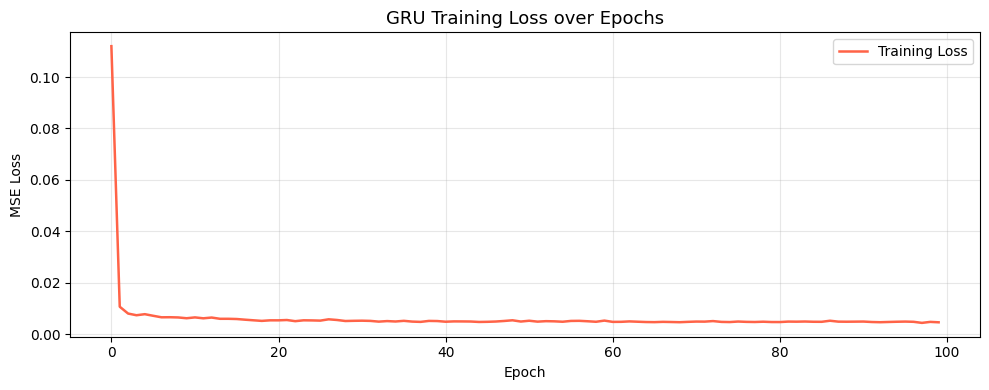

In [8]:
plt.figure(figsize=(10, 4))
plt.plot(train_losses, color='tomato', linewidth=1.8, label='Training Loss')
plt.title('GRU Training Loss over Epochs', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Evaluate & Visualize Predictions

Train MSE: 0.012496
Test  MSE: 0.011273


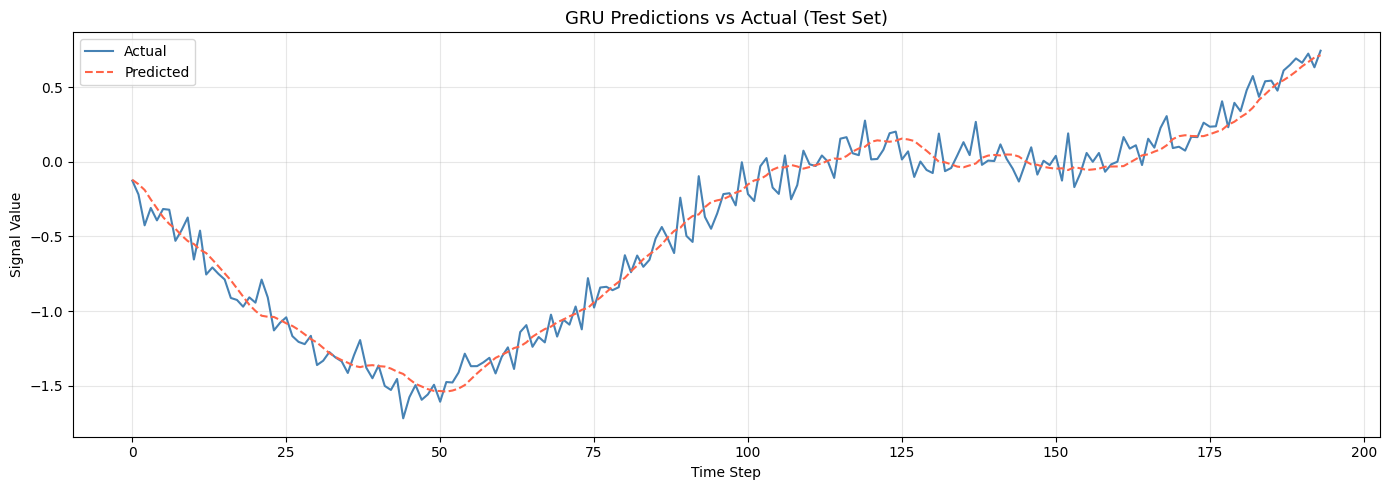

In [9]:
model.eval()
with torch.no_grad():
    train_pred = model(X_train_t).numpy()
    test_pred  = model(X_test_t).numpy()

# Inverse transform
train_pred_inv = scaler.inverse_transform(train_pred)
test_pred_inv  = scaler.inverse_transform(test_pred)
y_train_inv    = scaler.inverse_transform(y_train_t.numpy())
y_test_inv     = scaler.inverse_transform(y_test_t.numpy())

# MSE on original scale
train_mse = np.mean((train_pred_inv - y_train_inv) ** 2)
test_mse  = np.mean((test_pred_inv  - y_test_inv)  ** 2)
print(f'Train MSE: {train_mse:.6f}')
print(f'Test  MSE: {test_mse:.6f}')

# Plot
plt.figure(figsize=(14, 5))
plt.plot(y_test_inv,   label='Actual',    color='steelblue', linewidth=1.5)
plt.plot(test_pred_inv,label='Predicted', color='tomato',    linewidth=1.5, linestyle='--')
plt.title('GRU Predictions vs Actual (Test Set)', fontsize=13)
plt.xlabel('Time Step')
plt.ylabel('Signal Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Visualize GRU Gate Activations

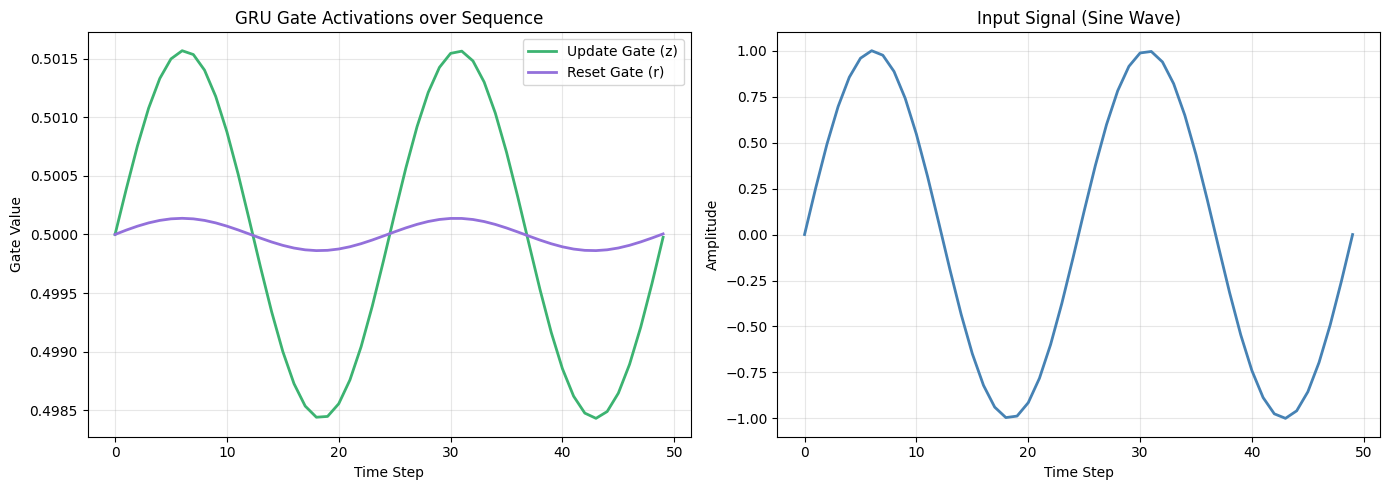

In [10]:
# Re-run one sample through NumPy GRU and collect gate values
np.random.seed(99)
demo_input = np.sin(np.linspace(0, 4 * np.pi, 50))
gru_viz    = GRUCellNumpy(input_size=1, hidden_size=8)

h_viz = np.zeros((8, 1))
update_gates, reset_gates = [], []

for val in demo_input:
    x_in = np.array([[val]])
    h_viz, z, r, _ = gru_viz.forward(x_in, h_viz)
    update_gates.append(z.mean())
    reset_gates.append(r.mean())

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(update_gates, color='mediumseagreen', linewidth=2, label='Update Gate (z)')
plt.plot(reset_gates,  color='mediumpurple',   linewidth=2, label='Reset Gate (r)')
plt.title('GRU Gate Activations over Sequence', fontsize=12)
plt.xlabel('Time Step')
plt.ylabel('Gate Value')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(demo_input, color='steelblue', linewidth=2)
plt.title('Input Signal (Sine Wave)', fontsize=12)
plt.xlabel('Time Step')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Save & Load Model

In [11]:
# Save model weights
torch.save(model.state_dict(), 'gru_model.pth')
print('Model saved to gru_model.pth')

# Load model
loaded_model = GRUModel()
loaded_model.load_state_dict(torch.load('gru_model.pth'))
loaded_model.eval()
print('Model loaded successfully!')

# Verify predictions match
with torch.no_grad():
    pred_orig   = model(X_test_t[:5]).numpy()
    pred_loaded = loaded_model(X_test_t[:5]).numpy()
    print(f'Predictions match: {np.allclose(pred_orig, pred_loaded)}')

Model saved to gru_model.pth
Model loaded successfully!
Predictions match: True


## Summary
| Component | Details |
|-----------|--------|
| NumPy GRU | Manual gate equations (z, r, h̃) |
| PyTorch GRU | `nn.GRU` with 2 layers, hidden=64 |
| Task | Univariate time-series prediction |
| Optimizer | Adam + StepLR scheduler |
| Regularization | Gradient clipping + Dropout |